# 02 · Face Swap Generation — Source–Target Pair Selection (P50 / P99)

For each source identity pick two target images: one at the 50th cosine-similarity percentile (P50, visually distinguishable) and one at the 99th (P99, near-indistinguishable). This two-band strategy gives the classifier examples at both ends of the difficulty spectrum.

In [1]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import glob
from PIL import Image
import pandas as pd
from tqdm import tqdm

In [2]:
celeba_face_embeddings = np.load('./face_embeddings_artifacts/celeba_face_embeddings_arcface.npz', allow_pickle=True)
flickr_face_embeddings = np.load('./face_embeddings_artifacts/flickr_face_embeddings_arcface.npz', allow_pickle=True)
utk_face_embeddings = np.load('./face_embeddings_artifacts/utk_face_embeddings_arcface.npz', allow_pickle=True)
vgg_face_embeddings = np.load('./face_embeddings_artifacts/vgg_face_embeddings_arcface.npz', allow_pickle=True)

In [3]:
embeddings = flickr_face_embeddings['embeddings']
image_names = flickr_face_embeddings['image_names']

In [4]:
similarity_matrix = embeddings @ embeddings.T

In [21]:
import numpy as np
import pandas as pd
from collections import Counter
import random
import math
from tqdm import tqdm  # opcional, para barra de progreso

# -------------------------
# Parámetros (ajusta si quieres)
# -------------------------
swaps_per_anchor = 6
per_anchor_requirements = {'hard': 3, 'medium': 2, 'easy': 1}
hard_th = 0.5
med_th  = 0.3
max_occurrences = 6         # <-- pedido: 6
allow_directed = True       # permite A->B y B->A como distintos
top_k_search = 500          # busca solo entre los top_k vecinos para eficiencia (ajusta)
seed = 42
shuffle_anchors = True      # baraja orden de anchors para balancear asignaciones

# -------------------------
# Helpers
# -------------------------
def categorize(sim, hard_th=0.5, med_th=0.3):
    if sim >= hard_th:
        return 'hard'
    elif sim >= med_th:
        return 'medium'
    else:
        return 'easy'

# -------------------------
# main function
# -------------------------
def build_faceswap_pairs_from_similarity(similarity_matrix, image_names,
                                         swaps_per_anchor=6,
                                         per_anchor_requirements={'hard':3,'medium':2,'easy':1},
                                         hard_th=0.5, med_th=0.3,
                                         max_occurrences=6,
                                         allow_directed=True,
                                         top_k_search=500,
                                         seed=42,
                                         shuffle_anchors=True):
    np.random.seed(seed)
    random.seed(seed)

    N = similarity_matrix.shape[0]
    assert len(image_names) == N

    # Precompute sorted neighbor indices (desc), excluding self
    neighbors = []
    for i in range(N):
        sims = similarity_matrix[i].copy()
        sims[i] = -np.inf
        order = np.argsort(-sims)  # descending
        if top_k_search is not None:
            order = order[:top_k_search]
        neighbors.append(order)

    # Order of anchors
    anchors = list(range(N))
    if shuffle_anchors:
        random.shuffle(anchors)

    occurrences = Counter()  # counts appearances as source OR target
    used_directed_pairs = set()  # (src,tgt) pairs used when allow_directed True
    used_unordered_pairs = set() # frozenset({src,tgt}) if directed not allowed

    swaps = []  # result rows: dicts
    
    # First greedy pass: satisfy category quotas
    for src in tqdm(anchors, desc="Pass 1 (by category)"):
        needed = per_anchor_requirements.copy()
        got = 0

        # if src already saturated, skip (rare given max_occurrences==swaps_per_anchor but possible)
        if occurrences[src] >= max_occurrences:
            continue

        for tgt in neighbors[src]:
            if got >= swaps_per_anchor:
                break
            if occurrences[src] >= max_occurrences:
                break
            if occurrences[tgt] >= max_occurrences:
                continue
            if tgt == src:
                continue

            sim = float(similarity_matrix[src, tgt])
            cat = categorize(sim, hard_th=hard_th, med_th=med_th)

            if needed.get(cat, 0) <= 0:
                continue  # we already have enough for this category

            # check duplicate pair constraints
            if allow_directed:
                if (src, tgt) in used_directed_pairs:
                    continue
            else:
                key = frozenset({int(src), int(tgt)})
                if key in used_unordered_pairs:
                    continue

            # Accept
            swaps.append({
                'source_idx': int(src),
                'target_idx': int(tgt),
                'image_source': image_names[int(src)],
                'image_target': image_names[int(tgt)],
                'similaridad': sim,
                'category': cat
            })
            got += 1
            needed[cat] -= 1
            occurrences[src] += 1
            occurrences[tgt] += 1
            if allow_directed:
                used_directed_pairs.add((src, tgt))
            else:
                used_unordered_pairs.add(key)

    # Second pass (fallback) per anchor: try to fill remaining slots with any available neighbor (respectando max_occurrences)
    for src in tqdm(anchors, desc="Pass 2 (fallback)"):
        # count how many already assigned as source for this anchor
        current_for_src = sum(1 for r in swaps if r['source_idx'] == src)
        to_fill = swaps_per_anchor - current_for_src
        if to_fill <= 0:
            continue
        if occurrences[src] >= max_occurrences:
            continue

        for tgt in neighbors[src]:
            if to_fill <= 0:
                break
            if occurrences[src] >= max_occurrences:
                break
            if occurrences[tgt] >= max_occurrences:
                continue
            if tgt == src:
                continue

            # skip if duplicate pair present
            if allow_directed:
                if (src, tgt) in used_directed_pairs:
                    continue
            else:
                key = frozenset({int(src), int(tgt)})
                if key in used_unordered_pairs:
                    continue

            sim = float(similarity_matrix[src, tgt])
            cat = categorize(sim, hard_th=hard_th, med_th=med_th)

            # Accept as fallback (any category)
            swaps.append({
                'source_idx': int(src),
                'target_idx': int(tgt),
                'image_source': image_names[int(src)],
                'image_target': image_names[int(tgt)],
                'similaridad': sim,
                'category': cat
            })
            to_fill -= 1
            occurrences[src] += 1
            occurrences[tgt] += 1
            if allow_directed:
                used_directed_pairs.add((src, tgt))
            else:
                used_unordered_pairs.add(frozenset({int(src), int(tgt)}))

    # Third pass (global relaxed filling): if still anchors missing slots, pick ANY target in whole dataset with occurrences < max_occurrences
    # This is unlikely with large N and top_k_search big, but included for robustness.
    anchors_still = []
    for src in anchors:
        current_for_src = sum(1 for r in swaps if r['source_idx'] == src)
        if current_for_src < swaps_per_anchor:
            anchors_still.append((src, current_for_src))
    if len(anchors_still) > 0:
        all_targets = list(range(N))
        for src, curr in tqdm(anchors_still, desc="Pass 3 (global relax)"):
            to_fill = swaps_per_anchor - curr
            if occurrences[src] >= max_occurrences:
                continue
            # shuffle global targets to randomize
            random.shuffle(all_targets)
            for tgt in all_targets:
                if to_fill <= 0:
                    break
                if occurrences[src] >= max_occurrences:
                    break
                if occurrences[tgt] >= max_occurrences:
                    continue
                if tgt == src:
                    continue
                if allow_directed and (src, tgt) in used_directed_pairs:
                    continue
                if not allow_directed and frozenset({int(src), int(tgt)}) in used_unordered_pairs:
                    continue

                sim = float(similarity_matrix[src, tgt])
                cat = categorize(sim, hard_th=hard_th, med_th=med_th)

                swaps.append({
                    'source_idx': int(src),
                    'target_idx': int(tgt),
                    'image_source': image_names[int(src)],
                    'image_target': image_names[int(tgt)],
                    'similaridad': sim,
                    'category': cat
                })
                to_fill -= 1
                occurrences[src] += 1
                occurrences[tgt] += 1
                if allow_directed:
                    used_directed_pairs.add((src, tgt))
                else:
                    used_unordered_pairs.add(frozenset({int(src), int(tgt)}))

    # Build DataFrame and report
    df = pd.DataFrame([{
        'image_source': r['image_source'],
        'image_target': r['image_target'],
        'similaridad': r['similaridad'],
        'category': r['category']
    } for r in swaps])

    # sanity checks
    per_anchor_counts = df.groupby('image_source').size().reindex(image_names, fill_value=0)
    anchors_incomplete = per_anchor_counts[per_anchor_counts < swaps_per_anchor]
    report = {
        'N_images': N,
        'requested_swaps_per_anchor': swaps_per_anchor,
        'total_pairs_generated': len(df),
        'anchors_with_full_swaps': int((per_anchor_counts == swaps_per_anchor).sum()),
        'anchors_incomplete_count': int((per_anchor_counts < swaps_per_anchor).sum()),
        'anchors_incomplete_sample': anchors_incomplete[anchors_incomplete < swaps_per_anchor].head(20).to_dict(),
        'top_occurrences': occurrences.most_common(20)
    }

    return df, report, occurrences

# -------------------------
# Ejecución (usa tus variables)
# -------------------------
# Asegúrate: similarity_matrix y image_names existen en tu scope
# Por ejemplo:
# similarity_matrix = embeddings @ embeddings.T
# image_names = flickr_face_embeddings['image_names']

df_pairs, report, occurrences = build_faceswap_pairs_from_similarity(
    similarity_matrix=similarity_matrix,
    image_names=image_names,
    swaps_per_anchor=swaps_per_anchor,
    per_anchor_requirements=per_anchor_requirements,
    hard_th=hard_th, med_th=med_th,
    max_occurrences=max_occurrences,
    allow_directed=allow_directed,
    top_k_search=top_k_search,
    seed=seed,
    shuffle_anchors=shuffle_anchors
)


Pass 3 (global relax): 100%|██████████| 13060/13060 [00:00<00:00, 185010.74it/s]


In [23]:
df_pairs['category'].value_counts()

category
medium    24078
easy       9473
hard       7702
Name: count, dtype: int64

In [26]:
df_pairs[df_pairs['category'] == 'hard']

,image_source,image_target,similaridad,category
9,68037.png,16535.png,0.631940,hard
10,68037.png,25419.png,0.607531,hard
11,68037.png,67508.png,0.570809,hard
14,14527.png,19005.png,0.672804,hard
15,14527.png,07274.png,0.547211,hard
...,...,...,...,...
38521,51152.png,68557.png,0.870426,hard
38522,51152.png,57300.png,0.843226,hard
38523,51152.png,61095.png,0.829574,hard
41135,57300.png,36245.png,0.937361,hard


In [39]:
Image.open(f'../00 ETL/FLICKR/cropped_and_aligned/51152.png').save('./girl.png')

In [40]:
Image.open(f'../00 ETL/FLICKR/cropped_and_aligned/36245.png').save('./man.png')

In [37]:
similarity_df = pd.DataFrame(similarity_matrix, columns = image_names)
final = []
for i in tqdm(similarity_df.columns):
    similarity_df[i] = np.where(similarity_df[i] == 1.0,0,similarity_df[i])
    max_sim = similarity_df[i].max()
    final.append({
        'file_name' : i,
        'max_sim' : max_sim
    })
    

100%|██████████| 13751/13751 [00:05<00:00, 2318.57it/s]


In [38]:
pd.DataFrame(final)

,file_name,max_sim
0,62454.png,0.448718
1,18863.png,1.000000
2,28242.png,1.000000
3,36640.png,1.000000
4,18100.png,1.000000
...,...,...
13746,47410.png,1.000000
13747,66516.png,0.431053
13748,62272.png,0.496300
13749,03298.png,1.000000


In [7]:
_ = 100
query = embeddings[_]
name_file_query = image_names[_]
scores = embeddings @ query

# excluir self-match
scores[_] = -np.inf

threshold = 0.5
valid_idx = np.where(scores > threshold)[0]

similar_names = image_names[valid_idx]
similar_scores = scores[valid_idx]

print("Cantidad encontrados:", len(similar_names))

for name, score in zip(similar_names, similar_scores):
    print(name, score)


Cantidad encontrados: 1
40582.png 0.5205993


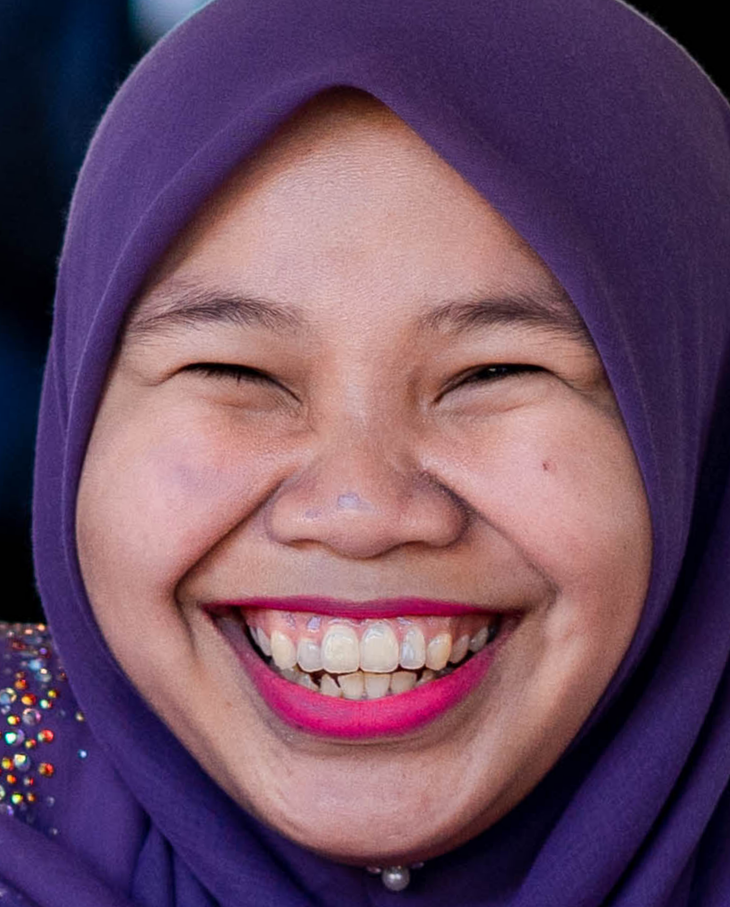

In [25]:
Image.open(f'../00 ETL/FLICKR/cropped_and_aligned/{name_file_query}')

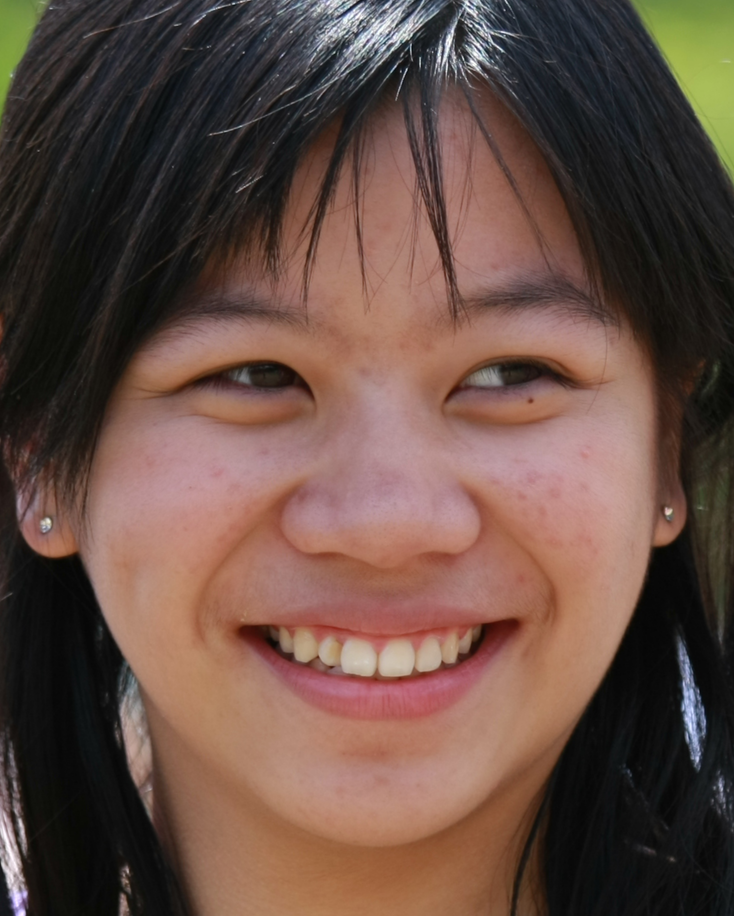

In [26]:
Image.open(f'../00 ETL/FLICKR/cropped_and_aligned/{similar_names[0]}')